# ECSE 415 Course Project: Classification, Detection, and Localization

In [14]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import time
import os
import shutil
import random
import torch
import torchvision.models as models
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn import metrics 
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
from PIL import Image

## Part 1: The Classification Benchmark [50 Points]

Path declaration for part 1:

In [2]:
path = './part1/'

In [3]:
cats = Path(path+'/train/train/cats')
cat_imgs = list(cats.iterdir())
dogs = Path(path+'/train/train/dogs')
dog_imgs = list(dogs.iterdir())

#shuffle all cat and dog images
random.shuffle(cat_imgs)
random.shuffle(dog_imgs)

#split- first 80% -> training, last 20* of list -> internal testing
split_cats = int(len(cat_imgs) * 0.8)
split_dogs = int(len(dog_imgs) * 0.8)
train_cats = cat_imgs[:split_cats]
test_cats = cat_imgs[split_cats:]
train_dogs = dog_imgs[:split_dogs]
test_dogs = dog_imgs[split_dogs:]

#use shutil to copy images in each list 
for img in train_cats:
    shutil.copy2(img, path+'train/train_split/cats')
for img in test_cats:
    shutil.copy2(img, path+'train/test_split/cats')
for img in train_dogs:
    shutil.copy2(img, path+'train/train_split/dogs')
for img in test_dogs:
    shutil.copy2(img, path+'train/test_split/dogs')


### 1. Method Selection (Training)

**Option A**:

**Option B**:

**Option C**: Fine-Tuned ResNet

In [4]:
# Step 1: Load pre-trained ResNet-18 and modify the final layer for binary classification
# ResNet-18 is chosen over deeper variants (ResNet-34, ResNet-50) to reduce computational
# cost. Performance gains from deeper architectures are marginal for this binary task. (https://arxiv.org/pdf/1512.03385 )
model = models.resnet50(pretrained=True)
num_classes = 2  # cats and dogs

# Replace the final fully connected layer to output 2 classes instead of ImageNet's 1000.
# in_features is preserved from the original layer.
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
# Step 2: Preprocess training and testing data
# Apply data augmentation to training data to improve generalization and reduce overfitting.
# Test data is only transformed through normalization.
# Reference for normalization values: https://pytorch.org/hub/pytorch_vision_resnet/
data_transforms = {
    # Apply data augmentation and normalization to training data
    'train': transforms.Compose([
        # Randomly crop and resize to 224x224 to vary scale and position across epochs
        transforms.RandomResizedCrop(224), 
        # Randomly apply horizontal flip- this does not affect the fact that image still looks like a cat, and helps with augmentation
        transforms.RandomHorizontalFlip(),          
        transforms.ToTensor(),
        # Normalize using ImageNet mean and std required for pretrained ResNet weights
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])      
    ]),
    # Apply just resize+crop and normalization for test set
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = ImageFolder(path+'train/train_split', transform=data_transforms['train'])
test_dataset = ImageFolder(path+'train/test_split', transform=data_transforms['test'])

# Shuffle training data so model sees images in different order at every epoch
# num_workers allows use of 4 cores
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [6]:
# Step 3: Loss function and optimizer
# Momentum value for optimizer chosen following tutorial: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [7]:
# Step 4: Model training

def train_model(model, train_loader, loss_function, optimizer, num_epochs):
    # Detect whether we can use GPU, or else use CPU
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Move model's weights/parameters to GPU memory, if available
    model = model.to(device)
    
    since = time.time()
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()
        
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)
        
        total_loss = 0.0
        correct = 0
        
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            # Move inputs and labels to device
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Reset the gradients to zero
            optimizer.zero_grad()
            # Forward pass
            predictions = model(inputs)
            _, predicted_classes = torch.max(predictions, dim=1) 
            # Calculate loss 
            loss = loss_function(predictions, labels)
            total_loss += loss.item() * inputs.size(0) 
            # Backpropagation
            loss.backward()
            # Update weights
            optimizer.step()
            # Get cumulative correct predictions
            correct += torch.sum(predicted_classes == labels.data)
            
        # Calculate avg training loss and accuracy for epoch
        training_loss = total_loss/len(train_loader.dataset)
        training_accuracy = correct.float() / len(train_loader.dataset)
        print(f'Train loss: {training_loss:.4f}, train acc: {training_accuracy:.4f}')
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    return model

# Train the model
model = train_model(model, train_loader, loss_function, optimizer, num_epochs=10)

# Save the trained model weights
torch.save(model.state_dict(), 'resnet50.pth')

Using device: mps
Epoch 1/10
--------------------


Epoch 1/10: 100%|██████████| 625/625 [05:33<00:00,  1.87it/s]


Train loss: 0.1247, train acc: 0.9498
Epoch 2/10
--------------------


Epoch 2/10: 100%|██████████| 625/625 [05:41<00:00,  1.83it/s]


Train loss: 0.0814, train acc: 0.9663
Epoch 3/10
--------------------


...

Train loss: 0.0510, train acc: 0.9796
Epoch 9/10
--------------------


Epoch 9/10: 100%|██████████| 625/625 [05:33<00:00,  1.88it/s]


Train loss: 0.0463, train acc: 0.9818
Epoch 10/10
--------------------


Epoch 10/10: 100%|██████████| 625/625 [05:42<00:00,  1.82it/s]


Train loss: 0.0497, train acc: 0.9792
Training complete in 56m 38s


In [8]:
# Evaluate model on test set
model.eval()
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

correct = 0
total = 0
# Used for confusion matrix
ResNet_preds = []
true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        # Collect predictions and true labels
        ResNet_preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 99.93%


In [23]:
# Load saved model
model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('resnet50.pth'))
model.eval()
model = model.to(device)

In [11]:
kaggle_test_images = Path(path + 'test/test/').iterdir()
ids = []
predictions = []

for img_path in kaggle_test_images:
    image = Image.open(img_path)
    image = data_transforms['test'](image)
    image = image.unsqueeze(0)
    image = image.to(device)
    id = img_path.stem
    with torch.no_grad():
        output = model(image)
        _, prediction = torch.max(output, 1)
    ids.append(id)
    predictions.append(prediction.item())
    
df = pd.DataFrame({'id': ids, 'label': predictions})
df.to_csv('submission.csv', index=False)

### 2. Local Analysis and Evaluation

A. 

B. 

C. ResNet-50 Confusion matrix

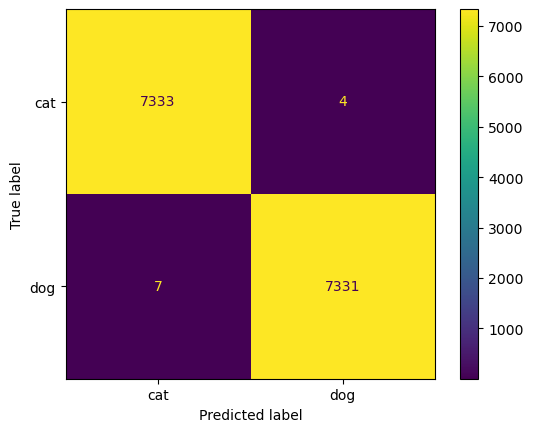

In [15]:
confusion_matrix = metrics.confusion_matrix(true_labels, ResNet_preds) 
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["cat", "dog"]) 
cm_display.plot()
plt.show() 

Total misclassified: 11


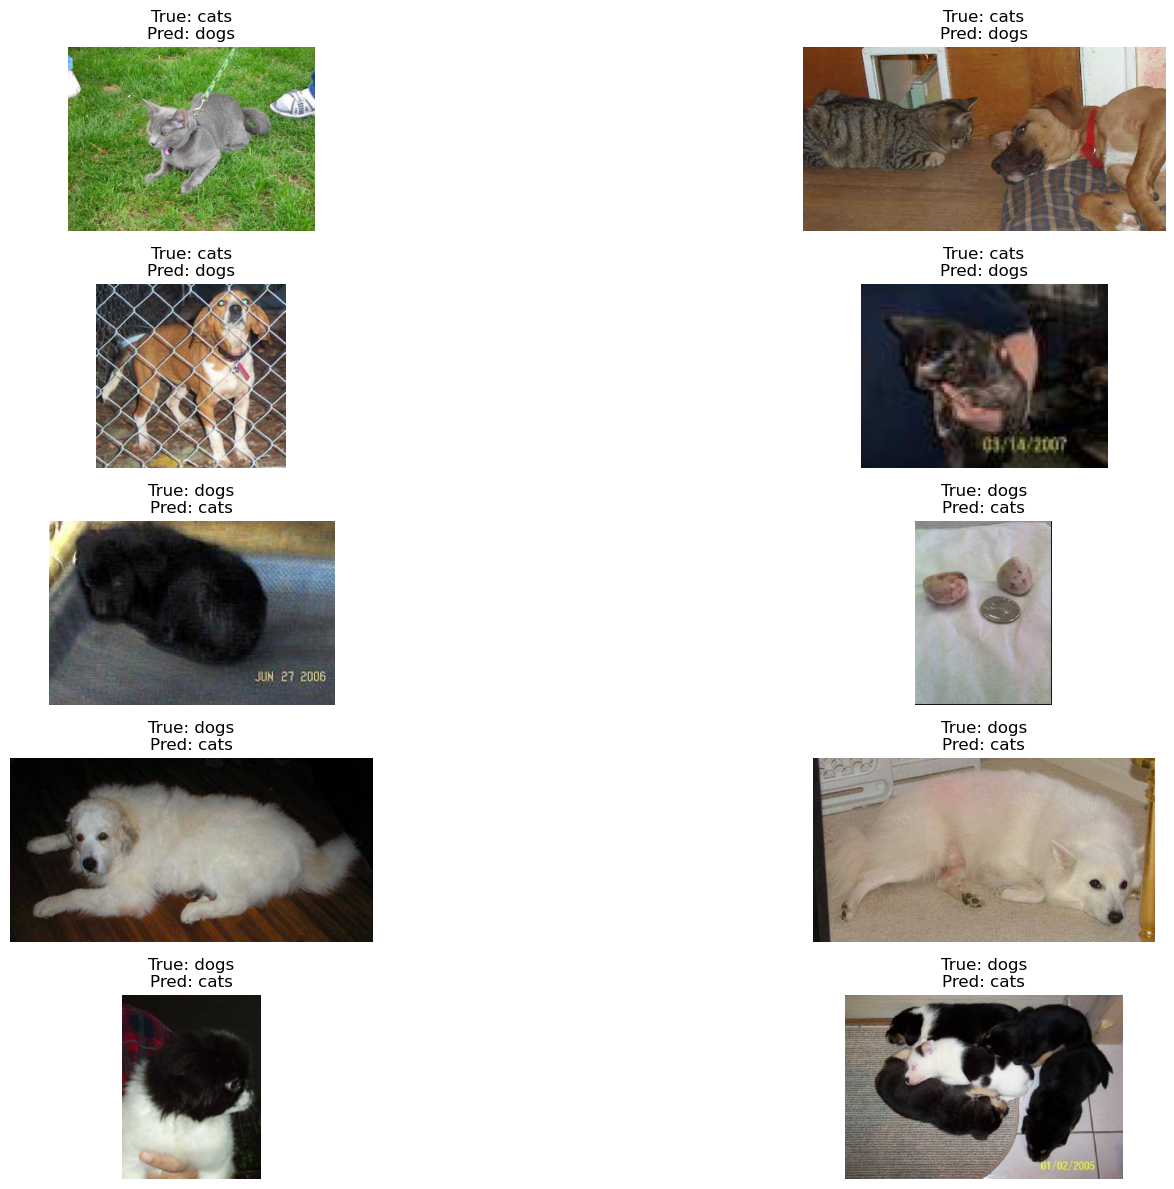

In [19]:
test_filepaths = [s[0] for s in test_dataset.samples]

misclassified = []
for i, (true, pred) in enumerate(zip(true_labels, ResNet_preds)):
    if true != pred:
        misclassified.append({
            'path': test_filepaths[i],
            'true': test_dataset.classes[true],
            'pred': test_dataset.classes[pred]
        })

print(f'Total misclassified: {len(misclassified)}')

fig, axes = plt.subplots(5, 2, figsize=(20, 12))
for ax, item in zip(axes.flatten(), misclassified[:10]):
    img = Image.open(item['path'])
    ax.imshow(img)
    ax.set_title(f"True: {item['true']}\nPred: {item['pred']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Part 2: Detection and Localization [50 Points]

In [4]:
path = './part2/'